In [4]:
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from IPython.display import display
FILES_TO_TEST = [
    'att48.tsp',
    'a280.tsp',
    'berlin52.tsp',
    'bier127.tsp',
    'd657.tsp',
    'gr431.tsp',
    'gr96.tsp',
    'pr1002.tsp',
    'pr226.tsp',
    'rd100.tsp',
    'rl1304.tsp',
    'u1060.tsp',
    'u2152.tsp'
]

# Fonction de chargement universelle
def load_instance_specific(filepath):
    coords = []
    reading_coords = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line == 'EOF': break
            if 'NODE_COORD_SECTION' in line:
                reading_coords = True
                continue
            if reading_coords:
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        coords.append([float(parts[1]), float(parts[2])])
                    except ValueError:
                        continue
    return np.array(coords)
print("✅ BLOC 1 CHARGÉ : Prêt à lire les fichiers.")

✅ BLOC 1 CHARGÉ : Prêt à lire les fichiers.


In [5]:
def calculate_cost(tour, matrix):
    return matrix[tour, np.roll(tour, -1)].sum()

def get_swap_sequence(curr, target, limit=4):
    swaps = []
    temp = curr[:]
    for i in range(len(temp)):
        if temp[i] != target[i]:
            val = target[i]
            if val in temp:
                idx = temp.index(val)
                temp[i], temp[idx] = temp[idx], temp[i]
                swaps.append((i, idx))
                if len(swaps) >= limit: break
    return swaps

def apply_swaps(tour, swaps):
    new = tour[:]
    for i, j in swaps:
        new[i], new[j] = new[j], new[i]
    return new

# --- Algorithme Glouton ---
def nearest_neighbor_tsp(matrix, start_node=0):
    t0 = time.time()
    n = len(matrix)
    visited = np.zeros(n, dtype=bool)
    tour = [start_node]
    visited[start_node] = True
    curr = start_node
    for _ in range(n - 1):
        dists = matrix[curr].copy()
        dists[visited] = np.inf
        next_city = np.argmin(dists)
        tour.append(next_city)
        visited[next_city] = True
        curr = next_city
    return tour, calculate_cost(tour, matrix), time.time() - t0

# --- Recherche Locale (2-opt) ---
def two_opt_local_search(tour, matrix, max_passes=2):
    best_tour = np.array(tour)
    best_cost = calculate_cost(best_tour, matrix)
    improved = True
    passes = 0
    n = len(tour)
    window = 100 if n > 500 else n
    while improved and passes < max_passes:
        improved = False
        passes += 1
        for i in range(1, n - 2):
            limit_j = min(i + window, n)
            for j in range(i + 1, limit_j):
                if j - i == 1: continue
                old_edges = matrix[best_tour[i-1], best_tour[i]] + matrix[best_tour[j-1], best_tour[j]]
                new_edges = matrix[best_tour[i-1], best_tour[j-1]] + matrix[best_tour[i], best_tour[j]]
                if new_edges < old_edges:
                    best_tour[i:j] = best_tour[i:j][::-1]
                    best_cost -= (old_edges - new_edges)
                    improved = True
    return best_tour.tolist(), best_cost

# --- Classe Particule (PSO) ---
class Particle:
    def __init__(self, n, matrix, init_tour=None):
        self.position = list(np.random.permutation(n)) if init_tour is None else init_tour[:]
        self.cost = calculate_cost(self.position, matrix)
        self.pbest_pos = self.position[:]
        self.pbest_cost = self.cost

# --- PSO Principal ---
def run_pso_full(matrix, mode='cold', glouton_tour=None, iterations=100, num_particles=30):
    start_time = time.time()
    n = len(matrix)
    particles = []
    history = []

    for i in range(num_particles):
        if i == 0 and mode != 'cold' and glouton_tour:
            p = Particle(n, matrix, glouton_tour)
        else:
            p = Particle(n, matrix)
        particles.append(p)

    gbest = min(particles, key=lambda x: x.pbest_cost)
    gbest_pos = gbest.pbest_pos[:]
    gbest_cost = gbest.pbest_cost
    stag_count = 0

    for it in range(iterations):
        w = 0.9 - (it / iterations) * 0.5
        improved_global = False

        for p in particles:
            swaps_p = get_swap_sequence(p.position, p.pbest_pos, limit=2)
            swaps_g = get_swap_sequence(p.position, gbest_pos, limit=2)
            to_apply = []
            if random.random() > 0.3: to_apply += swaps_p
            if random.random() > (1 - w): to_apply += swaps_g
            p.position = apply_swaps(p.position, to_apply)
            p.cost = calculate_cost(p.position, matrix)

            if p.cost < p.pbest_cost:
                p.pbest_cost = p.cost
                p.pbest_pos = p.position[:]
                if p.pbest_cost < gbest_cost:
                    gbest_cost = p.pbest_cost
                    gbest_pos = p.pbest_pos[:]
                    improved_global = True

        if mode in ['hybrid', 'improved']:
            if improved_global or (it % 20 == 0):
                opt_tour, opt_cost = two_opt_local_search(gbest_pos, matrix, max_passes=1)
                if opt_cost < gbest_cost:
                    gbest_cost = opt_cost
                    gbest_pos = opt_tour[:]
                    improved_global = True

        if not improved_global:
            stag_count += 1
        else:
            stag_count = 0

        if mode == 'improved' and stag_count > 15:
            for i in range(1, len(particles)//2):
                particles[i].position = list(np.random.permutation(n))
                particles[i].cost = calculate_cost(particles[i].position, matrix)
            stag_count = 0

        history.append(gbest_cost)

    return gbest_cost, np.mean([p.pbest_cost for p in particles]), history, time.time() - start_time, gbest_pos

print("✅ BLOC 2 CHARGÉ : Algorithmes prêts.")

✅ BLOC 2 CHARGÉ : Algorithmes prêts.


--- 🚀 DÉMARRAGE DE LA CAMPAGNE COMPLÈTE SUR 13 FICHIERS ---


📂 TRAITEMENT : att48.tsp
📊 Taille : 48 villes
   ✅ 1. Glouton     : 40526 (Temps: 0.0011s)
   ✅ 2. PSO Cold    : 87250
   ✅ 3. PSO Warm    : 40356
   ✅ 4. PSO Amélioré: 34577 🏆 (Temps: 0.24s)


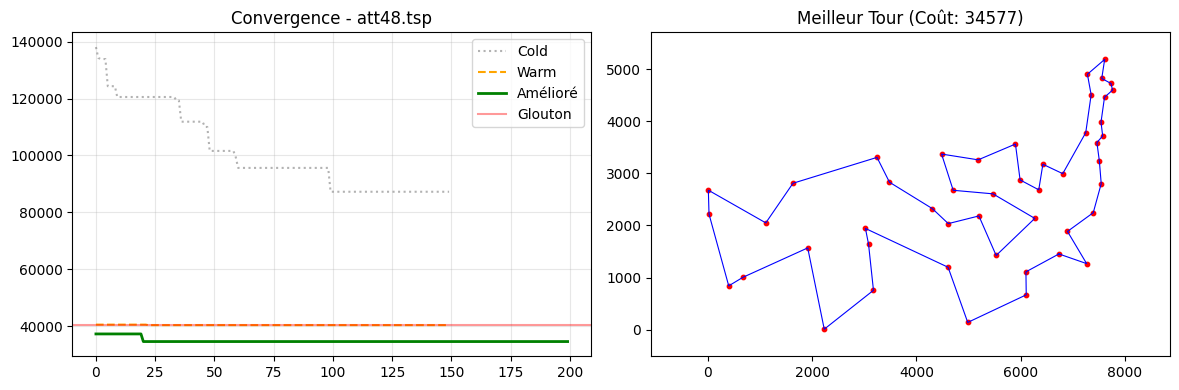


📂 TRAITEMENT : a280.tsp
📊 Taille : 280 villes
   ✅ 1. Glouton     : 3148 (Temps: 0.0032s)
   ✅ 2. PSO Cold    : 31897
   ✅ 3. PSO Warm    : 3148
   ✅ 4. PSO Amélioré: 2797 🏆 (Temps: 0.87s)


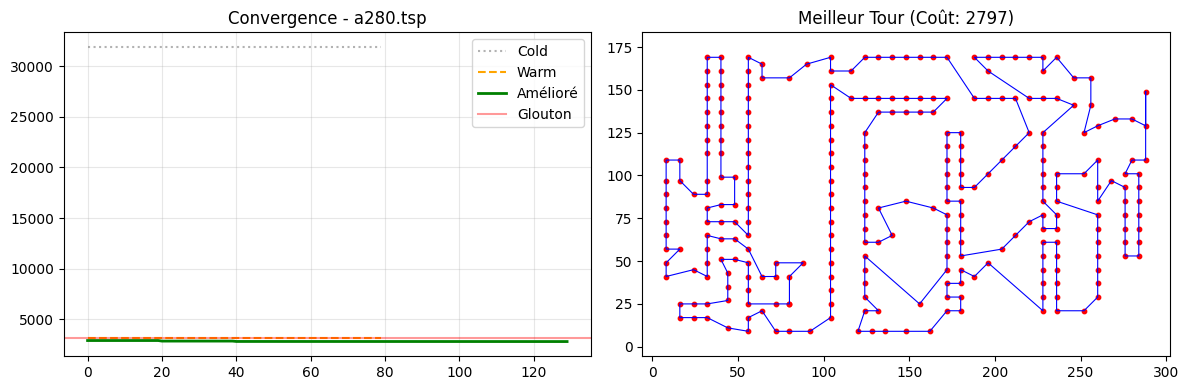


📂 TRAITEMENT : berlin52.tsp
📊 Taille : 52 villes
   ✅ 1. Glouton     : 8981 (Temps: 0.0005s)
   ✅ 2. PSO Cold    : 22196
   ✅ 3. PSO Warm    : 8745
   ✅ 4. PSO Amélioré: 8148 🏆 (Temps: 0.25s)


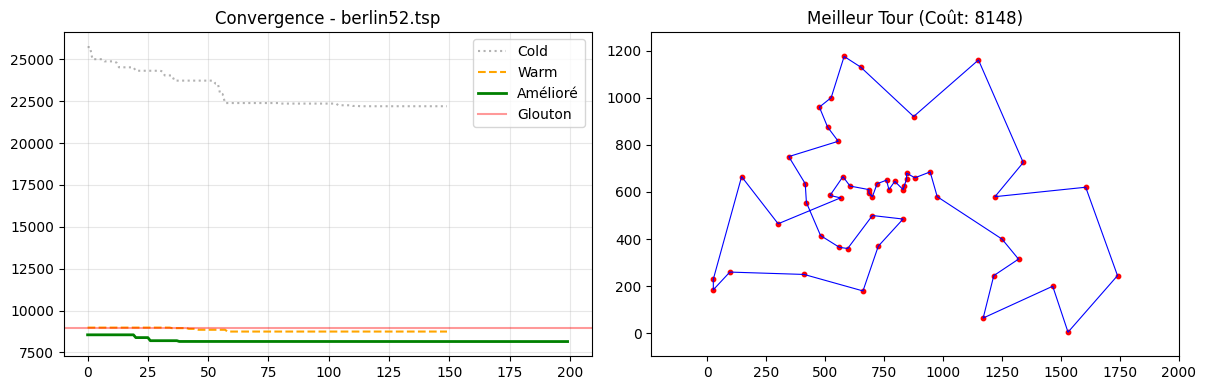


📂 TRAITEMENT : bier127.tsp
📊 Taille : 127 villes
   ✅ 1. Glouton     : 135752 (Temps: 0.0012s)
   ✅ 2. PSO Cold    : 533350
   ✅ 3. PSO Warm    : 129360
   ✅ 4. PSO Amélioré: 126075 🏆 (Temps: 0.50s)


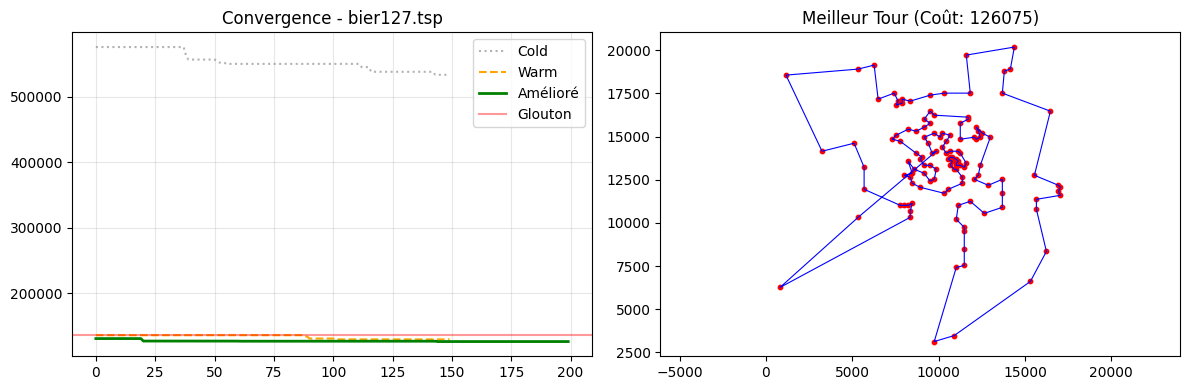


📂 TRAITEMENT : d657.tsp
📊 Taille : 657 villes
   ✅ 1. Glouton     : 62176 (Temps: 0.0036s)
   ✅ 2. PSO Cold    : 816106
   ✅ 3. PSO Warm    : 62176
   ✅ 4. PSO Amélioré: 58253 🏆 (Temps: 2.05s)


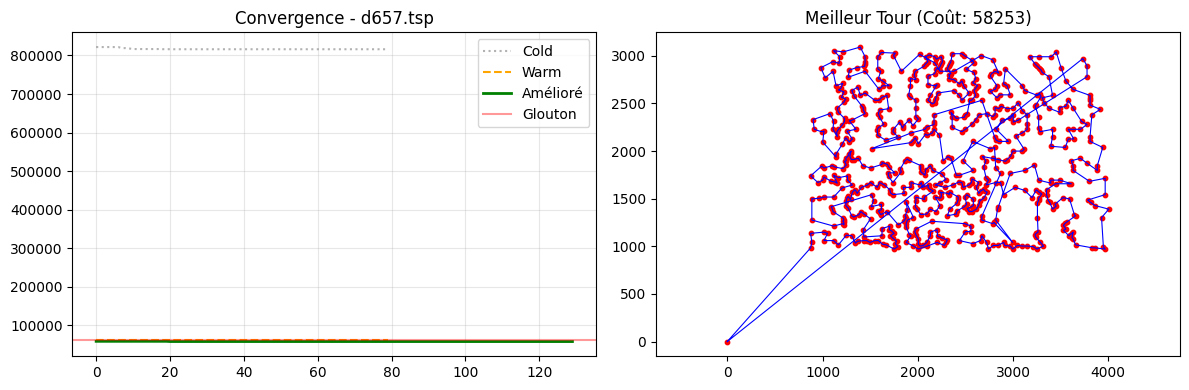


📂 TRAITEMENT : gr431.tsp
📊 Taille : 431 villes
   ✅ 1. Glouton     : 2516 (Temps: 0.0032s)
   ✅ 2. PSO Cold    : 27235
   ✅ 3. PSO Warm    : 2516
   ✅ 4. PSO Amélioré: 2134 🏆 (Temps: 1.72s)


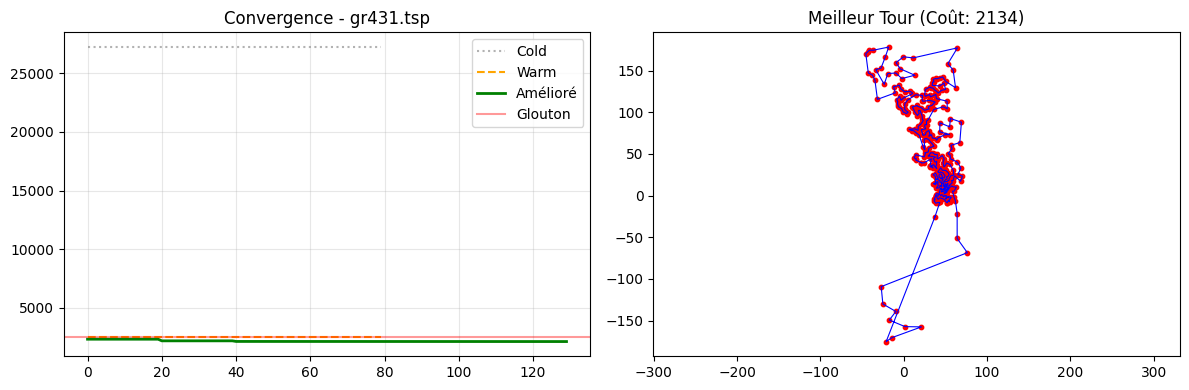


📂 TRAITEMENT : gr96.tsp
📊 Taille : 96 villes
   ✅ 1. Glouton     : 707 (Temps: 0.0008s)
   ✅ 2. PSO Cold    : 2584
   ✅ 3. PSO Warm    : 650
   ✅ 4. PSO Amélioré: 601 🏆 (Temps: 0.50s)


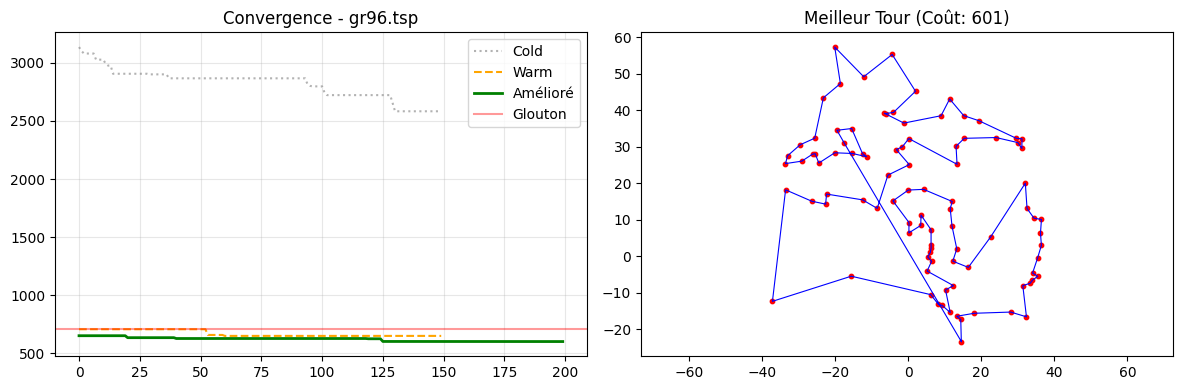


📂 TRAITEMENT : pr1002.tsp
📊 Taille : 1002 villes
   ✅ 1. Glouton     : 315597 (Temps: 0.0054s)
   ✅ 2. PSO Cold    : 6237064
   ✅ 3. PSO Warm    : 315597
   ✅ 4. PSO Amélioré: 286335 🏆 (Temps: 2.52s)


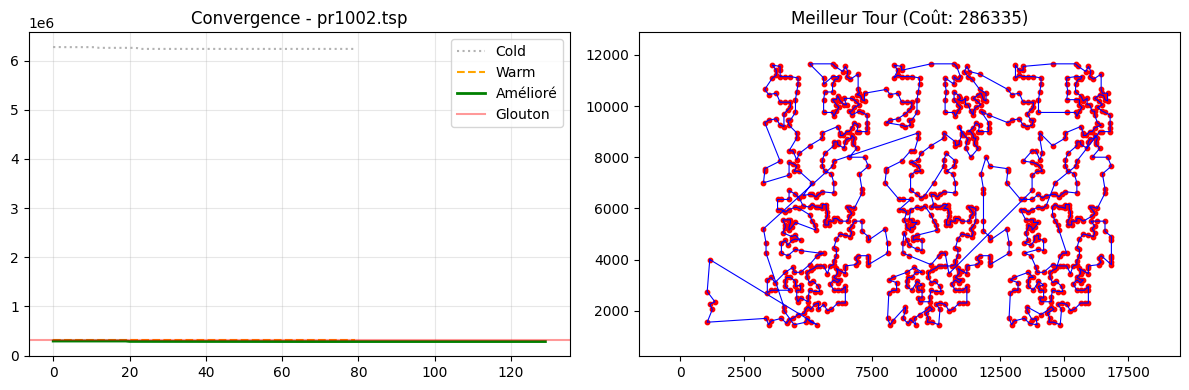


📂 TRAITEMENT : pr226.tsp
📊 Taille : 226 villes
   ✅ 1. Glouton     : 94685 (Temps: 0.0017s)
   ✅ 2. PSO Cold    : 1578675
   ✅ 3. PSO Warm    : 94685
   ✅ 4. PSO Amélioré: 87543 🏆 (Temps: 0.63s)


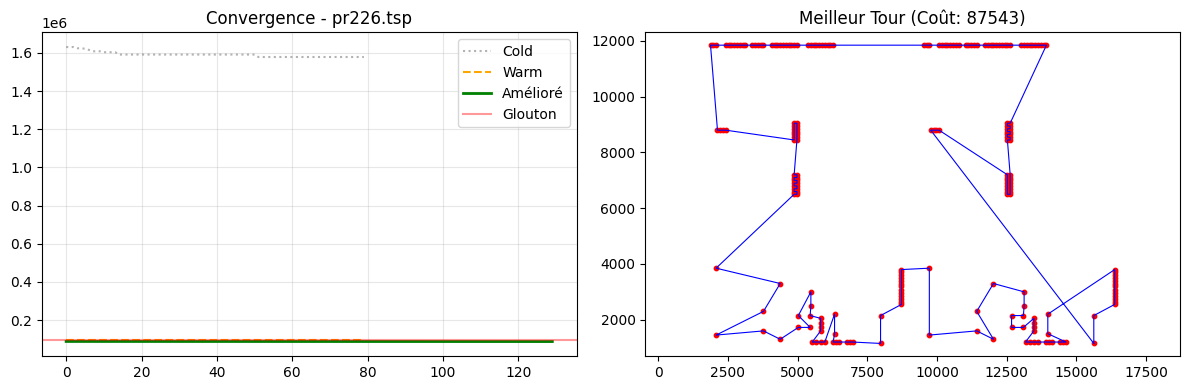


📂 TRAITEMENT : rd100.tsp
📊 Taille : 100 villes
   ✅ 1. Glouton     : 9941 (Temps: 0.0009s)
   ✅ 2. PSO Cold    : 43703
   ✅ 3. PSO Warm    : 9941
   ✅ 4. PSO Amélioré: 8492 🏆 (Temps: 0.55s)


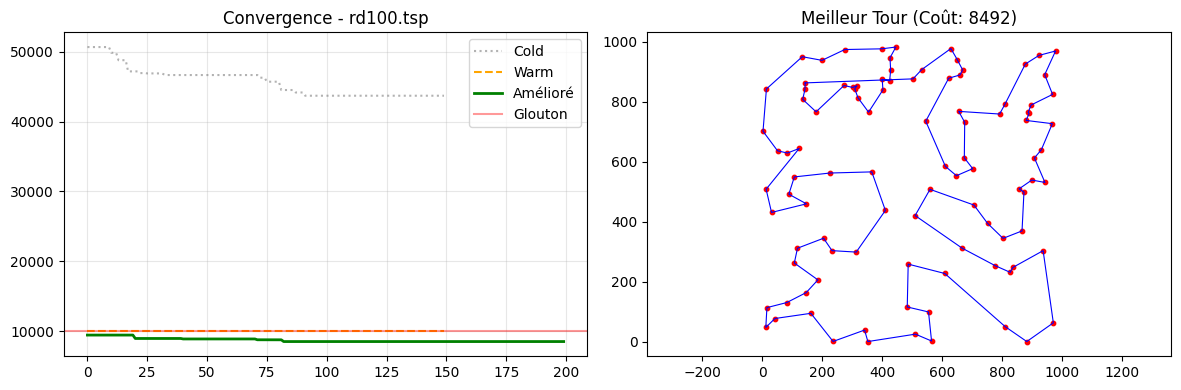


📂 TRAITEMENT : rl1304.tsp
📊 Taille : 1304 villes
   ✅ 1. Glouton     : 339797 (Temps: 0.0143s)
   ✅ 2. PSO Cold    : 9170390
   ✅ 3. PSO Warm    : 339797
   ✅ 4. PSO Amélioré: 318279 🏆 (Temps: 3.20s)


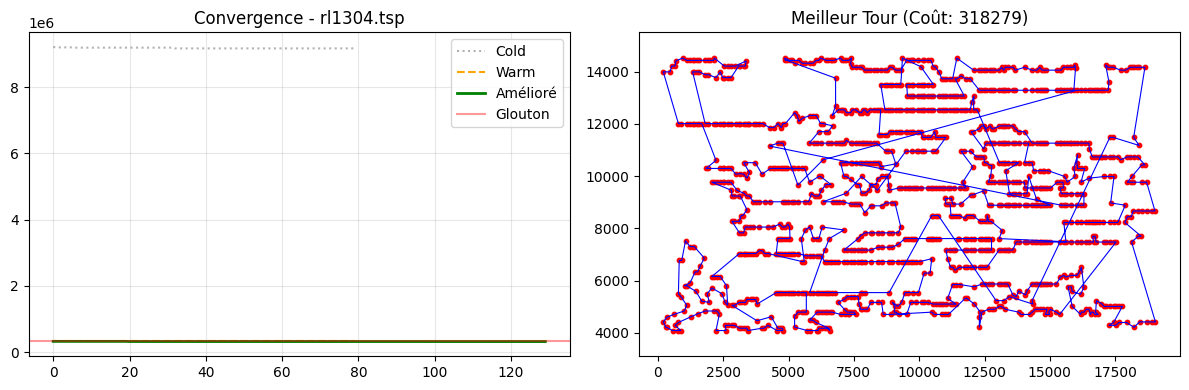


📂 TRAITEMENT : u1060.tsp
📊 Taille : 1060 villes
   ✅ 1. Glouton     : 281636 (Temps: 0.0059s)
   ✅ 2. PSO Cold    : 6546041
   ✅ 3. PSO Warm    : 281636
   ✅ 4. PSO Amélioré: 264528 🏆 (Temps: 2.57s)


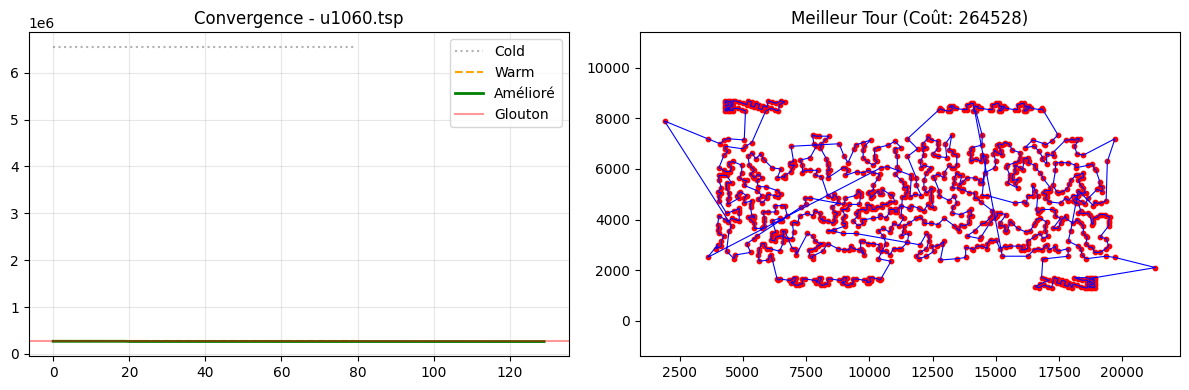


📂 TRAITEMENT : u2152.tsp
📊 Taille : 2152 villes
   ✅ 1. Glouton     : 80180 (Temps: 0.0198s)
   ✅ 2. PSO Cold    : 2478441
   ✅ 3. PSO Warm    : 80180
   ✅ 4. PSO Amélioré: 76148 🏆 (Temps: 5.32s)


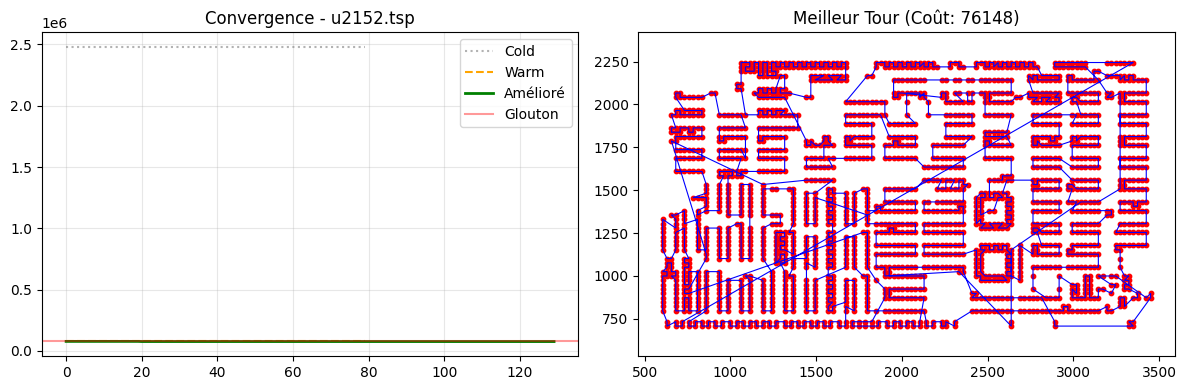


################################################################################
🏆 TABLEAU RÉCAPITULATIF FINAL (COÛTS ET TEMPS)
################################################################################


,Instance,Villes,Glouton,PSO Imp.,Gain (%),T. Glouton (s),T. PSO (s)
0,att48.tsp,48,40526,34577,14.6800,0.0011,0.2354
1,a280.tsp,280,3148,2797,11.1521,0.0032,0.8720
2,berlin52.tsp,52,8981,8148,9.2714,0.0005,0.2540
3,bier127.tsp,127,135752,126075,7.1280,0.0012,0.5021
4,d657.tsp,657,62176,58253,6.3102,0.0036,2.0491
5,gr431.tsp,431,2516,2134,15.1777,0.0032,1.7245
6,gr96.tsp,96,707.0900,601.0810,14.9923,0.0008,0.5045
7,pr1002.tsp,1002,315597,286335,9.2719,0.0054,2.5167
8,pr226.tsp,226,94685,87543,7.5433,0.0017,0.6349
9,rd100.tsp,100,9941,8492,14.5730,0.0009,0.5504


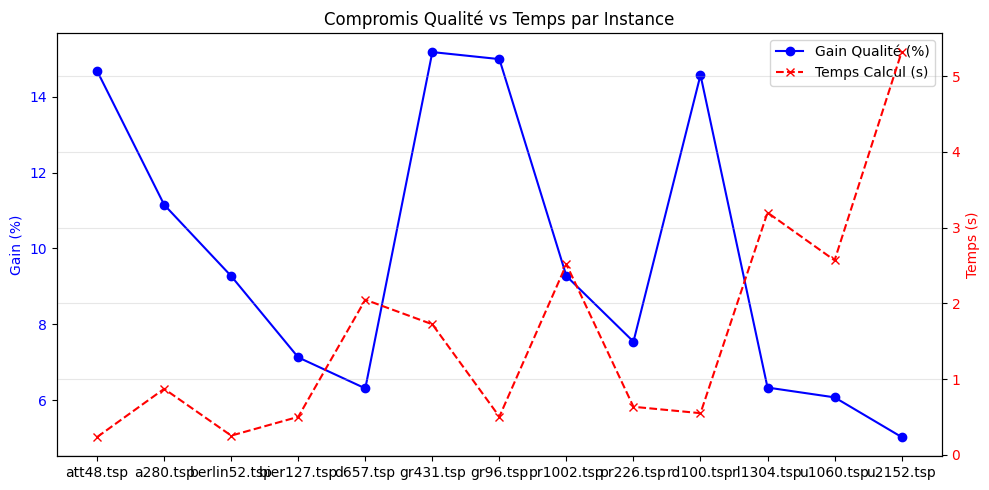


################################################################################
📊 STATISTIQUES GLOBALES (RÉSUMÉ)
################################################################################
Résumé statistique sur l'ensemble des instances :


,Gain (%),T. PSO (s),T. Glouton (s)
Minimum,5.03,0.24,0.00
Maximum,15.18,5.32,0.02
Moyenne,9.81,1.61,0.00



💡 CONCLUSION RAPIDE :
En moyenne, votre algorithme améliore la solution gloutonne de 9.81%.
Le temps moyen de calcul est de 1.61 secondes.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Liste pour stocker le résumé de chaque fichier
global_stats = []

print(f"--- 🚀 DÉMARRAGE DE LA CAMPAGNE COMPLÈTE SUR {len(FILES_TO_TEST)} FICHIERS ---\n")

for filename in FILES_TO_TEST:
    print(f"\n{'='*80}")
    print(f"📂 TRAITEMENT : {filename}")
    print(f"{'='*80}")

    # 1. Chargement
    try:
        coords = load_instance_specific(filename)
        if len(coords) == 0:
            print(f"⚠️ Fichier vide ou illisible : {filename}")
            continue
        dist_matrix = distance_matrix(coords, coords)
    except Exception as e:
        print(f"❌ Erreur critique sur {filename}: {e}")
        continue

    N_VILLES = len(dist_matrix)
    print(f"📊 Taille : {N_VILLES} villes")

    # Paramètres adaptatifs
    ITER = 150 if N_VILLES < 200 else 80
    POP = 30

    # --- A) GLOUTON ---
    print("   🔹 1. Glouton...", end="\r")
    tour_g, cost_g, time_g = nearest_neighbor_tsp(dist_matrix)
    print(f"   ✅ 1. Glouton     : {cost_g:.0f} (Temps: {time_g:.4f}s)")

    # --- B) PSO COLD ---
    print("   🔹 2. PSO Cold...", end="\r")
    min_c, _, hist_c, t_c, _ = run_pso_full(dist_matrix, 'cold', iterations=ITER, num_particles=POP)
    print(f"   ✅ 2. PSO Cold    : {min_c:.0f}")

    # --- C) PSO WARM ---
    print("   🔹 3. PSO Warm...", end="\r")
    min_w, _, hist_w, t_w, _ = run_pso_full(dist_matrix, 'warm', glouton_tour=tour_g, iterations=ITER, num_particles=POP)
    print(f"   ✅ 3. PSO Warm    : {min_w:.0f}")

    # --- D) PSO AMÉLIORÉ ---
    print("   🔹 4. PSO Amélioré...", end="\r")
    min_i, _, hist_i, t_i, best_tour = run_pso_full(dist_matrix, 'improved', glouton_tour=tour_g, iterations=ITER+50, num_particles=POP)
    print(f"   ✅ 4. PSO Amélioré: {min_i:.0f} 🏆 (Temps: {t_i:.2f}s)")

    gain_pct = ((cost_g - min_i) / cost_g) * 100

    # --- STOCKAGE (Modifié pour inclure les temps) ---
    global_stats.append({
        "Instance": filename,
        "Villes": N_VILLES,
        "Glouton": cost_g,
        "PSO Cold": min_c,
        "PSO Warm": min_w,
        "PSO Imp.": min_i,
        "Gain (%)": gain_pct,
        "T. Glouton (s)": time_g,  # Ajout du temps Glouton
        "T. PSO (s)": t_i          # Ajout du temps PSO Final
    })

    # --- VISUALISATION INDIVIDUELLE ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist_c, label='Cold', color='gray', linestyle=':', alpha=0.6)
    plt.plot(hist_w, label='Warm', color='orange', linestyle='--')
    plt.plot(hist_i, label='Amélioré', color='green', linewidth=2)
    plt.axhline(y=cost_g, color='red', alpha=0.4, label='Glouton')
    plt.title(f"Convergence - {filename}")
    plt.legend()
    plt.grid(alpha=0.3)

    # Carte du meilleur tour
    plt.subplot(1, 2, 2)
    plt.scatter(coords[:, 0], coords[:, 1], c='red', s=10)
    if best_tour is not None:
        idx = best_tour + [best_tour[0]]
        plt.plot(coords[idx, 0], coords[idx, 1], c='blue', linewidth=0.8)
    plt.title(f"Meilleur Tour (Coût: {min_i:.0f})")
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

# =============================================================================
# AFFICHAGE DU GRAND TABLEAU FINAL (Modifié)
# =============================================================================

print("\n" + "#"*80)
print("🏆 TABLEAU RÉCAPITULATIF FINAL (COÛTS ET TEMPS)")
print("#"*80)

if len(global_stats) > 0:
    df_final = pd.DataFrame(global_stats)

    # Sélection et Ordre des colonnes (Avec les temps)
    cols = [
        'Instance',
        'Villes',
        'Glouton',
        'PSO Imp.',
        'Gain (%)',
        'T. Glouton (s)',
        'T. PSO (s)'
    ]

    # On filtre pour ne garder que ces colonnes
    df_final = df_final[cols]

    # Affichage propre
    # Formatage : 0 décimale pour les grands nombres, 4 décimales pour les petits (temps)
    pd.set_option('display.float_format', lambda x: '%.0f' % x if x > 1000 else '%.4f' % x)

    display(df_final)

    # --- GRAPHIQUE COMPARATIF TEMPS VS GAIN ---
    # (Optionnel : Un graphique pour visualiser le compromis)
    plt.figure(figsize=(10, 5))

    # Axe Y1 : Le Gain
    ax1 = plt.gca()
    l1 = ax1.plot(df_final['Instance'], df_final['Gain (%)'], 'b-o', label='Gain Qualité (%)')
    ax1.set_ylabel('Gain (%)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Axe Y2 : Le Temps PSO
    ax2 = ax1.twinx()
    l2 = ax2.plot(df_final['Instance'], df_final['T. PSO (s)'], 'r--x', label='Temps Calcul (s)')
    ax2.set_ylabel('Temps (s)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    plt.title("Compromis Qualité vs Temps par Instance")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # Légende combinée
    lns = l1 + l2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc=0)

    plt.tight_layout()
    plt.show()
# =============================================================================
# AJOUT : STATISTIQUES GLOBALES (MIN, MAX, MOYENNE)
# =============================================================================

print("\n" + "#"*80)
print("📊 STATISTIQUES GLOBALES (RÉSUMÉ)")
print("#"*80)

# On sélectionne les colonnes pertinentes pour les statistiques
# (On ne fait pas de moyenne sur les coûts car cela dépend de la taille de l'instance)
cols_stats = ['Gain (%)', 'T. PSO (s)', 'T. Glouton (s)']

if len(df_final) > 0:
    # Calcul de Min, Max, Moyenne
    stats_summary = df_final[cols_stats].agg(['min', 'max', 'mean'])

    # Renommer les index pour le français
    stats_summary.index = ['Minimum', 'Maximum', 'Moyenne']

    # Affichage avec un formatage propre
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    print("Résumé statistique sur l'ensemble des instances :")
    display(stats_summary)

    # Petit commentaire automatique
    avg_gain = stats_summary.loc['Moyenne', 'Gain (%)']
    print(f"\n💡 CONCLUSION RAPIDE :")
    print(f"En moyenne, votre algorithme améliore la solution gloutonne de {avg_gain:.2f}%.")
    print(f"Le temps moyen de calcul est de {stats_summary.loc['Moyenne', 'T. PSO (s)']:.2f} secondes.")
else:
    print("Aucun résultat à afficher.")